In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [16]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

# Download dataset via kagglehub
path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')
print('Dataset path:', path)

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv
Dataset path: /kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data


In [17]:
import os

# kagglehub stores dataset at path returned above
# Also check standard Kaggle input dir
search_dirs = [
    '/kaggle/input',
    path  # from kagglehub.dataset_download above
]

csv_path = None
for d in search_dirs:
    candidate = os.path.join(d, 'Country-data.csv')
    if os.path.exists(candidate):
        csv_path = candidate
        break

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'Loaded: {csv_path}')
else:
    raise FileNotFoundError('Country-data.csv not found. Run the kagglehub cell first.')

print(f'Shape: {df.shape}')
df.head()

Loaded: /kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


In [18]:
# Standardise column names
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

# Expected numeric columns
numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("=== Shape ===", df.shape)
print("\n=== Missing values ===")
print(df.isna().sum())
print("\n=== Basic statistics ===")
display(df[numeric_cols].describe().T.round(2))

=== Shape === (167, 10)

=== Missing values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== Basic statistics ===


,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


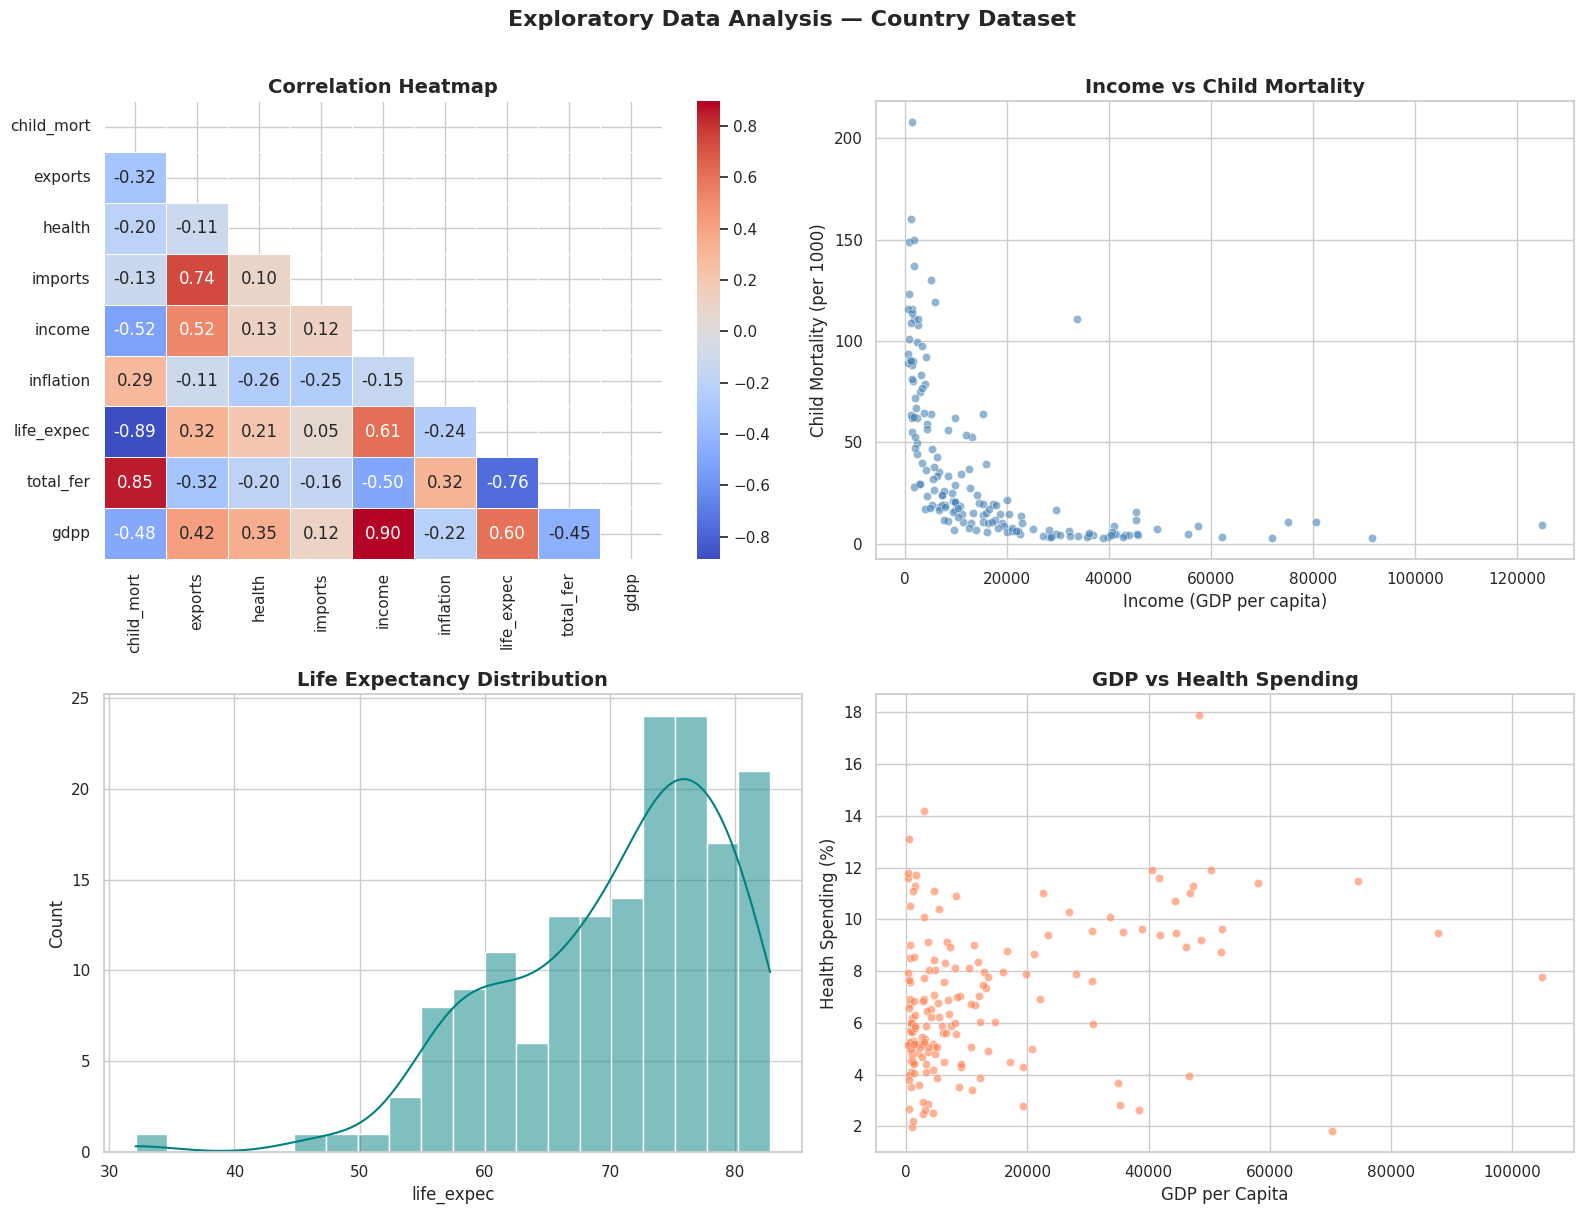

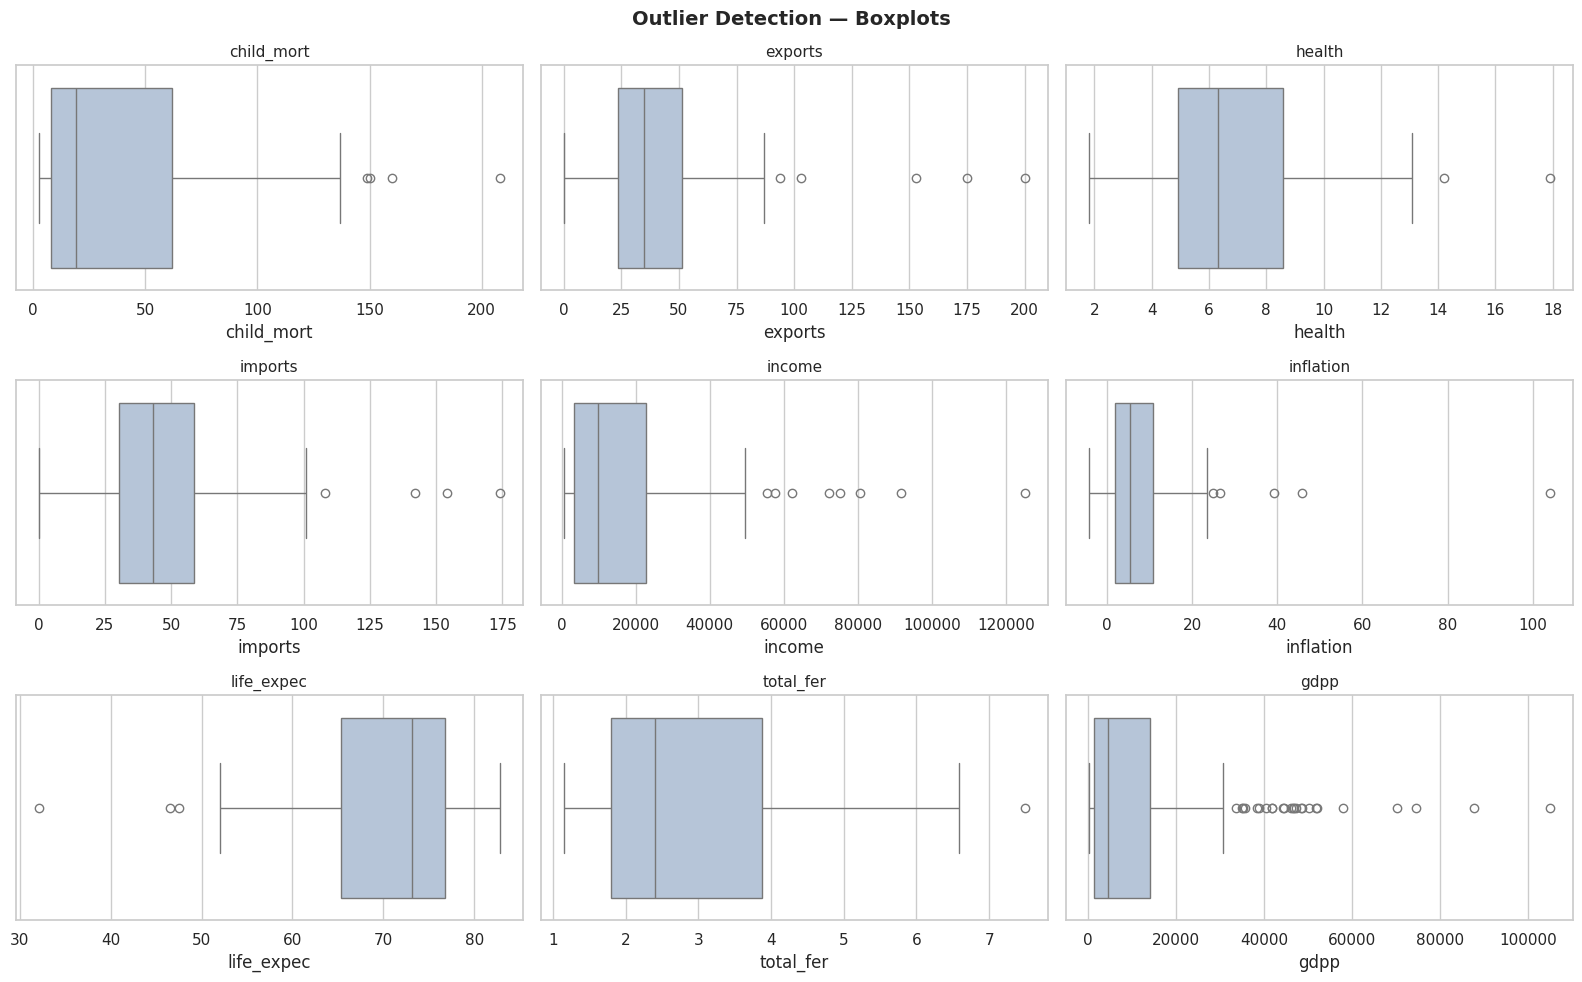

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation heatmap
ax = axes[0, 0]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# 2. Distribution: income vs child mortality
ax = axes[0, 1]
ax.scatter(df['income'], df['child_mort'], alpha=0.6, c='steelblue', edgecolors='white', linewidth=0.5)
ax.set_xlabel('Income (GDP per capita)')
ax.set_ylabel('Child Mortality (per 1000)')
ax.set_title('Income vs Child Mortality', fontsize=14, fontweight='bold')

# 3. Life expectancy distribution
ax = axes[1, 0]
sns.histplot(df['life_expec'], kde=True, ax=ax, color='teal', bins=20)
ax.set_title('Life Expectancy Distribution', fontsize=14, fontweight='bold')

# 4. GDP per capita vs Health spending
ax = axes[1, 1]
ax.scatter(df['gdpp'], df['health'], alpha=0.6, c='coral', edgecolors='white', linewidth=0.5)
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Health Spending (%)')
ax.set_title('GDP vs Health Spending', fontsize=14, fontweight='bold')

plt.suptitle('Exploratory Data Analysis — Country Dataset', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Boxplots for outlier detection
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(x=df[col], ax=ax, color='lightsteelblue')
    ax.set_title(col, fontsize=11)
plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Class distribution:
tier_label
Developed         64
Underdeveloped    53
Developing        50
Name: count, dtype: int64


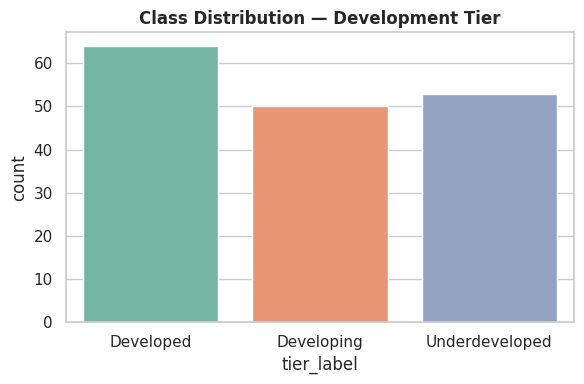

In [20]:
def assign_tier(row):
    """Rule-based development tier labelling."""
    if row['income'] > 15000 and row['child_mort'] < 25:
        return 0  # Developed
    elif row['income'] > 4000 and row['child_mort'] < 60:
        return 1  # Developing
    else:
        return 2  # Underdeveloped

df['dev_tier'] = df.apply(assign_tier, axis=1)
tier_names = {0: 'Developed', 1: 'Developing', 2: 'Underdeveloped'}
df['tier_label'] = df['dev_tier'].map(tier_names)

print("Class distribution:")
print(df['tier_label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='tier_label', data=df, palette='Set2',
              order=['Developed', 'Developing', 'Underdeveloped'])
plt.title('Class Distribution — Development Tier', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
X = df[numeric_cols].values
y = df['dev_tier'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Classes: {np.unique(y, return_counts=True)}")

Train size: 133 | Test size: 34
Classes: (array([0, 1, 2]), array([64, 50, 53]))


In [22]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         GaussianNB(),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
}

cls_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_scaled, y, cv=5, scoring='accuracy')
    acc = accuracy_score(y_test, preds)
    cls_results[name] = {
        'Test Accuracy': round(acc, 4),
        'CV Mean':       round(cv_scores.mean(), 4),
        'CV Std':        round(cv_scores.std(), 4)
    }
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f" Test Accuracy : {acc:.4f}")
    print(f" CV Mean±Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, preds,
                                 target_names=['Developed', 'Developing', 'Underdeveloped']))

cls_df = pd.DataFrame(cls_results).T
print("\n=== Classification Summary ===")
display(cls_df)


 Logistic Regression
 Test Accuracy : 0.8235
 CV Mean±Std   : 0.8857 ± 0.0524
                precision    recall  f1-score   support

     Developed       0.92      0.85      0.88        13
    Developing       0.64      0.90      0.75        10
Underdeveloped       1.00      0.73      0.84        11

      accuracy                           0.82        34
     macro avg       0.85      0.82      0.82        34
  weighted avg       0.86      0.82      0.83        34


 Naive Bayes
 Test Accuracy : 0.7941
 CV Mean±Std   : 0.8561 ± 0.0357
                precision    recall  f1-score   support

     Developed       0.91      0.77      0.83        13
    Developing       0.62      0.80      0.70        10
Underdeveloped       0.90      0.82      0.86        11

      accuracy                           0.79        34
     macro avg       0.81      0.80      0.80        34
  weighted avg       0.82      0.79      0.80        34


 KNN (k=5)
 Test Accuracy : 0.8529
 CV Mean±Std   : 0.8260 

,Test Accuracy,CV Mean,CV Std
Logistic Regression,0.82,0.89,0.05
Naive Bayes,0.79,0.86,0.04
KNN (k=5),0.85,0.83,0.06
SVM (RBF),0.85,0.86,0.08
Decision Tree,0.97,0.96,0.04


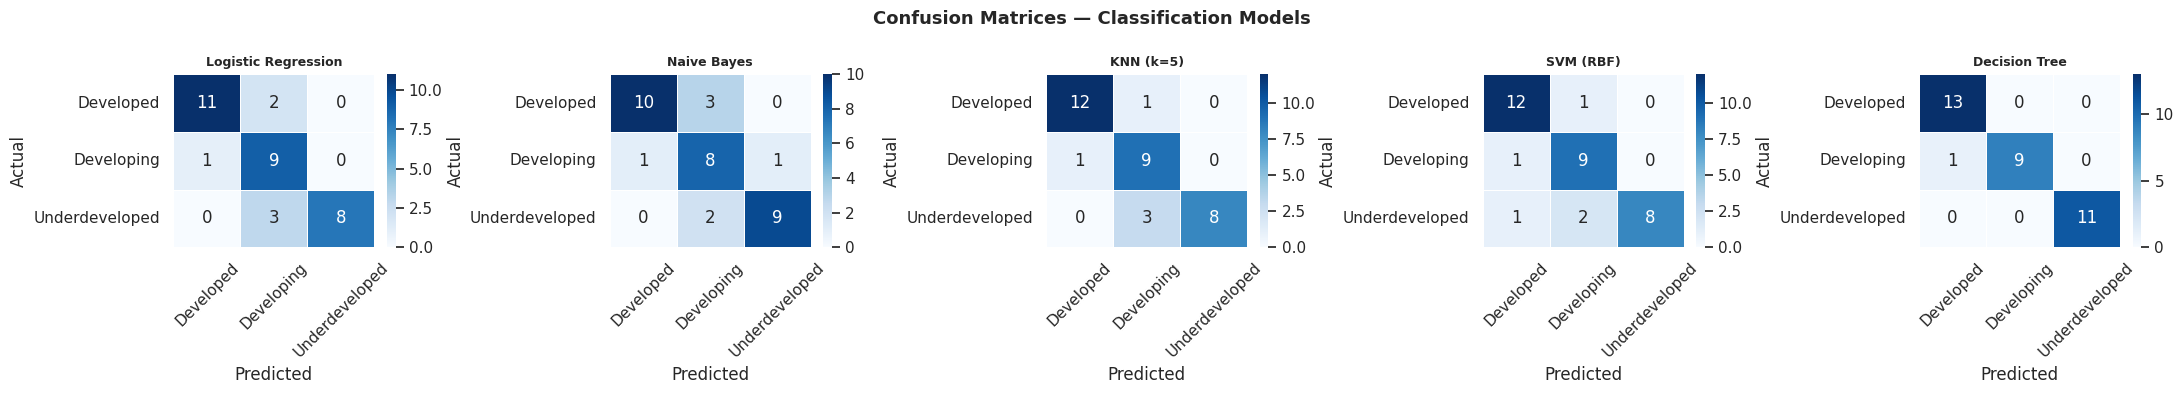

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
labels = ['Developed', 'Developing', 'Underdeveloped']

for ax, (name, clf) in zip(axes, classifiers.items()):
    preds = clf.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Classification Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

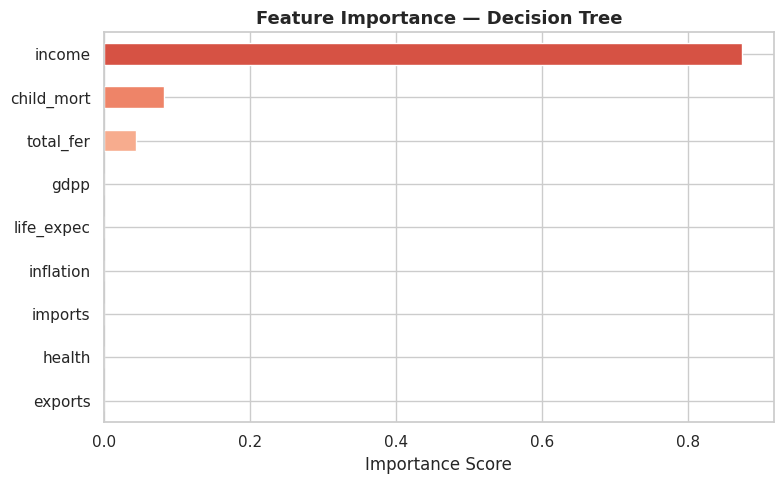

In [24]:
dt = classifiers['Decision Tree']
feat_imp = pd.Series(dt.feature_importances_, index=numeric_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color=sns.color_palette('coolwarm', len(feat_imp)))
plt.title('Feature Importance — Decision Tree', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [25]:
# Base estimators for stacking
base_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
]

ensemble_models = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                    random_state=42, n_jobs=-1),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42,
                                               algorithm='SAMME'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                        learning_rate=0.1, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                                              use_label_encoder=False, eval_metric='mlogloss',
                                              random_state=42, verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                                               random_state=42, verbose=-1),
    'Stacking':            StackingClassifier(
                               estimators=base_estimators,
                               final_estimator=LogisticRegression(max_iter=1000),
                               cv=5, n_jobs=-1
                           ),
}

ens_results = {}
for name, model in ensemble_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    acc  = accuracy_score(y_test, preds)
    ens_results[name] = {
        'Test Accuracy': round(acc, 4),
        'CV Mean':       round(cv.mean(), 4),
        'CV Std':        round(cv.std(), 4)
    }
    print(f"\n{'='*45}")
    print(f" {name}")
    print(f"{'='*45}")
    print(f" Test Accuracy : {acc:.4f}")
    print(f" CV Mean±Std   : {cv.mean():.4f} ± {cv.std():.4f}")
    print(classification_report(y_test, preds,
                                 target_names=['Developed', 'Developing', 'Underdeveloped']))

ens_df = pd.DataFrame(ens_results).T
print("\n=== Ensemble Summary ===")
display(ens_df)


 Random Forest
 Test Accuracy : 0.9412
 CV Mean±Std   : 0.9520 ± 0.0411
                precision    recall  f1-score   support

     Developed       0.93      1.00      0.96        13
    Developing       0.90      0.90      0.90        10
Underdeveloped       1.00      0.91      0.95        11

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34


 AdaBoost
 Test Accuracy : 0.9412
 CV Mean±Std   : 0.9522 ± 0.0143
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        13
    Developing       0.90      0.90      0.90        10
Underdeveloped       0.91      0.91      0.91        11

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34


 Gradient Boosting
 Test Accuracy : 0.9706
 CV Mean±Std   : 0.9881 ±

,Test Accuracy,CV Mean,CV Std
Random Forest,0.94,0.95,0.04
AdaBoost,0.94,0.95,0.01
Gradient Boosting,0.97,0.99,0.01
XGBoost,0.97,0.96,0.03
LightGBM,0.97,0.97,0.04
Stacking,0.94,0.96,0.05


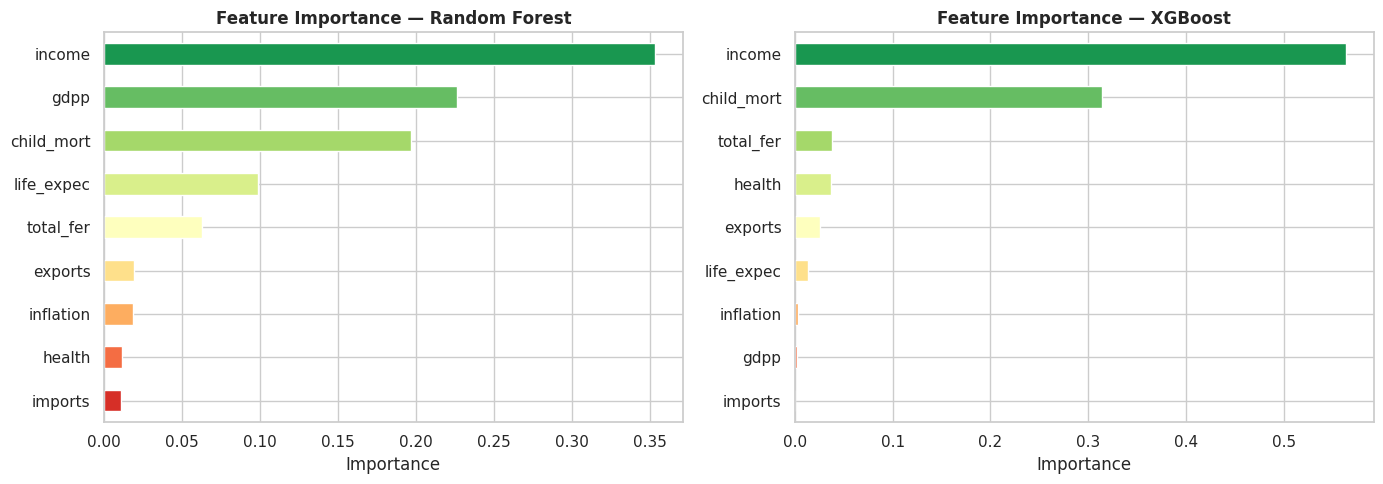

In [26]:
rf = ensemble_models['Random Forest']
xgb_model = ensemble_models['XGBoost']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, title) in zip(axes, [
    (rf,        'Random Forest'),
    (xgb_model, 'XGBoost')
]):
    imp = pd.Series(model.feature_importances_, index=numeric_cols).sort_values(ascending=True)
    colors = sns.color_palette('RdYlGn', len(imp))
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Feature Importance — {title}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

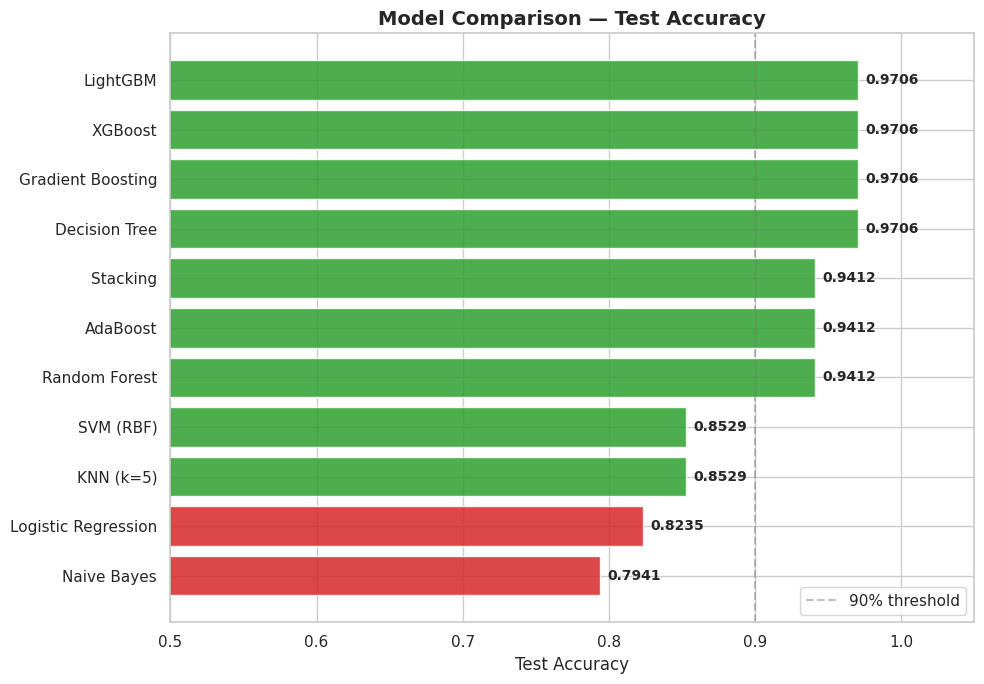


Best model: Decision Tree — 0.9706


In [27]:
all_results = {**cls_results, **ens_results}
results_df = pd.DataFrame(all_results).T.sort_values('Test Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in results_df['Test Accuracy']]
bars = ax.barh(results_df.index, results_df['Test Accuracy'], color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0.5, 1.05)
ax.axvline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nBest model:", results_df['Test Accuracy'].idxmax(),
      "—", results_df['Test Accuracy'].max())

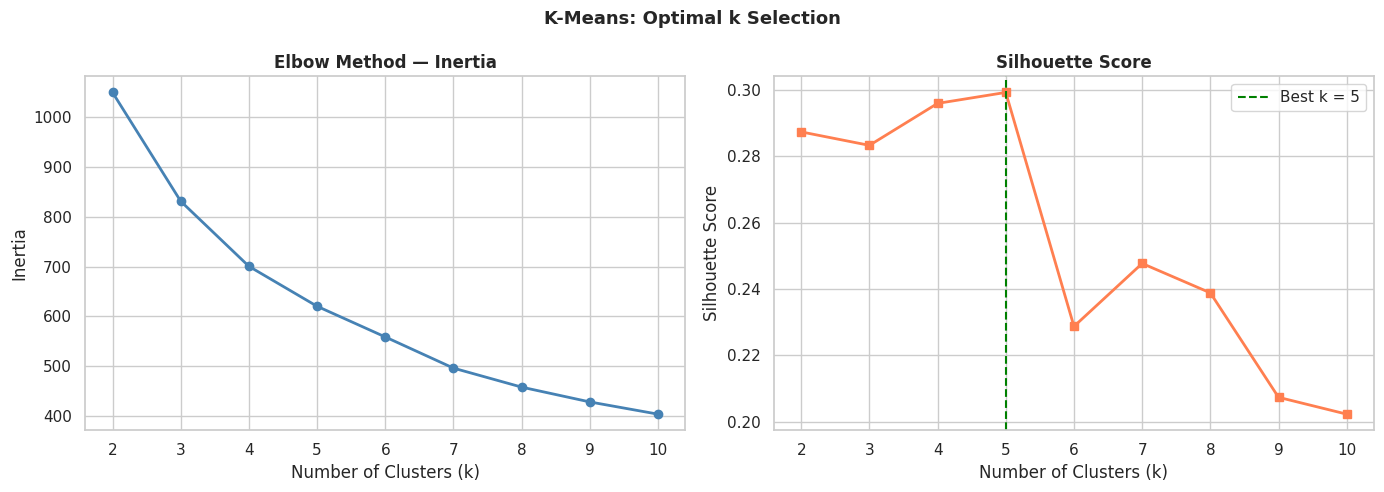

Best k by silhouette: 5


In [28]:
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='s', color='coral', linewidth=2)
best_k = k_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('K-Means: Optimal k Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Best k by silhouette: {best_k}")

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
db  = davies_bouldin_score(X_scaled, df['kmeans_cluster'])

print(f"K-Means (k={best_k})")
print(f"  Silhouette Score   : {sil:.4f}  (higher = better, max 1)")
print(f"  Davies-Bouldin     : {db:.4f}   (lower = better)")
print("\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())

if 'country' in df.columns:
    print("\nSample countries per cluster:")
    for c in sorted(df['kmeans_cluster'].unique()):
        countries = df[df['kmeans_cluster']==c]['country'].head(5).tolist()
        print(f"  Cluster {c}: {countries}")

K-Means (k=5)
  Silhouette Score   : 0.2993  (higher = better, max 1)
  Davies-Bouldin     : 0.8718   (lower = better)

Cluster sizes:
kmeans_cluster
0    84
1    47
2     3
3    32
4     1
Name: count, dtype: int64

Sample countries per cluster:
  Cluster 0: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia']
  Cluster 1: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']
  Cluster 2: ['Luxembourg', 'Malta', 'Singapore']
  Cluster 3: ['Australia', 'Austria', 'Bahamas', 'Belgium', 'Brunei']
  Cluster 4: ['Nigeria']


In [30]:
if KMEDOIDS_AVAILABLE:
    kmed = KMedoids(n_clusters=best_k, random_state=42)
    df['kmedoids_cluster'] = kmed.fit_predict(X_scaled)
    sil_km = silhouette_score(X_scaled, df['kmedoids_cluster'])
    db_km  = davies_bouldin_score(X_scaled, df['kmedoids_cluster'])
    print(f"K-Medoids (k={best_k})")
    print(f"  Silhouette Score   : {sil_km:.4f}")
    print(f"  Davies-Bouldin     : {db_km:.4f}")
else:
    # Fall back: use K-Means result
    df['kmedoids_cluster'] = df['kmeans_cluster']
    print("K-Medoids not installed — using K-Means clusters as proxy")
    print("Install: pip install scikit-learn-extra")

K-Medoids not installed — using K-Means clusters as proxy
Install: pip install scikit-learn-extra


In [31]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution (−1 = noise):")
print(df['dbscan_cluster'].value_counts().sort_index())

n_noise  = (df['dbscan_cluster'] == -1).sum()
n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
print(f"\nClusters found: {n_clusters} | Noise points: {n_noise}")

# Silhouette (exclude noise)
mask = df['dbscan_cluster'] != -1
if mask.sum() > 1 and len(df.loc[mask, 'dbscan_cluster'].unique()) > 1:
    db_sil = silhouette_score(X_scaled[mask], df.loc[mask, 'dbscan_cluster'])
    print(f"Silhouette (non-noise): {db_sil:.4f}")
else:
    print("Not enough clusters for silhouette score — try adjusting eps/min_samples")

DBSCAN cluster distribution (−1 = noise):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Clusters found: 1 | Noise points: 30
Not enough clusters for silhouette score — try adjusting eps/min_samples


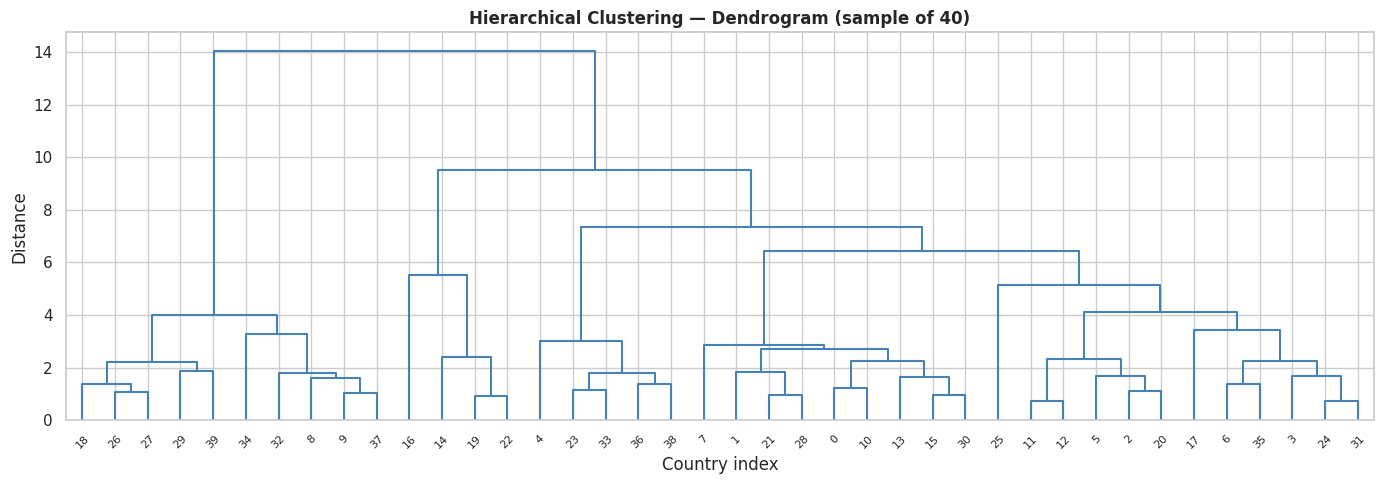

Hierarchical (k=5): Silhouette=0.2193  DB=1.3008


In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram (sample 40 for readability)
sample_idx = np.random.choice(len(X_scaled), size=min(40, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color='steelblue')
ax.set_title('Hierarchical Clustering — Dendrogram (sample of 40)', fontweight='bold')
ax.set_xlabel('Country index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Fit full agglomerative
agglo = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['agglo_cluster'] = agglo.fit_predict(X_scaled)
sil_a = silhouette_score(X_scaled, df['agglo_cluster'])
db_a  = davies_bouldin_score(X_scaled, df['agglo_cluster'])
print(f"Hierarchical (k={best_k}): Silhouette={sil_a:.4f}  DB={db_a:.4f}")

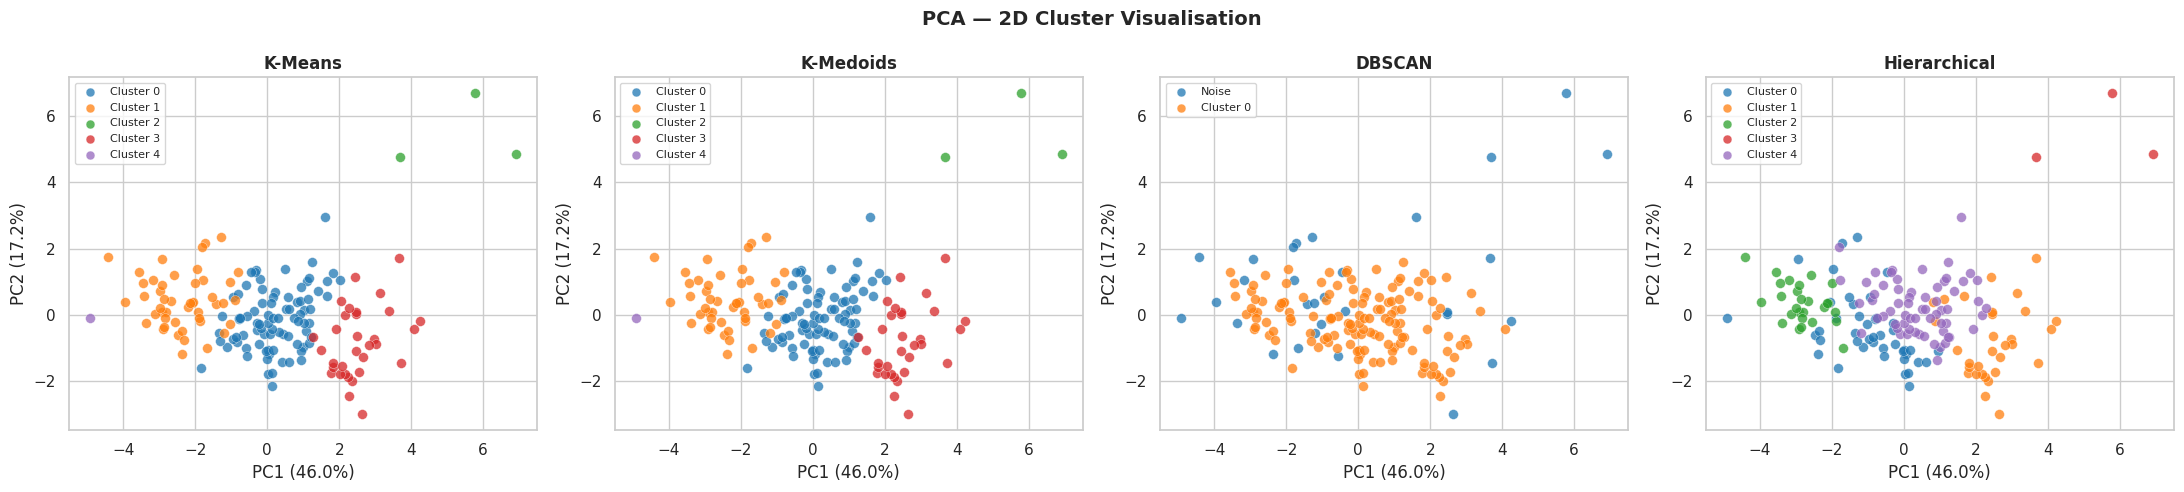

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

cluster_cols = ['kmeans_cluster', 'kmedoids_cluster', 'dbscan_cluster', 'agglo_cluster']
titles = ['K-Means', 'K-Medoids', 'DBSCAN', 'Hierarchical']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, col, title in zip(axes, cluster_cols, titles):
    unique_labels = sorted(df[col].unique())
    palette = sns.color_palette('tab10', len(unique_labels))
    for label, color in zip(unique_labels, palette):
        mask = df[col] == label
        lname = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=lname, color=color, alpha=0.75, s=50, edgecolors='white', linewidth=0.3)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    ax.legend(fontsize=8, markerscale=0.9)

plt.suptitle('PCA — 2D Cluster Visualisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== K-Means Cluster Profiles (mean values) ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


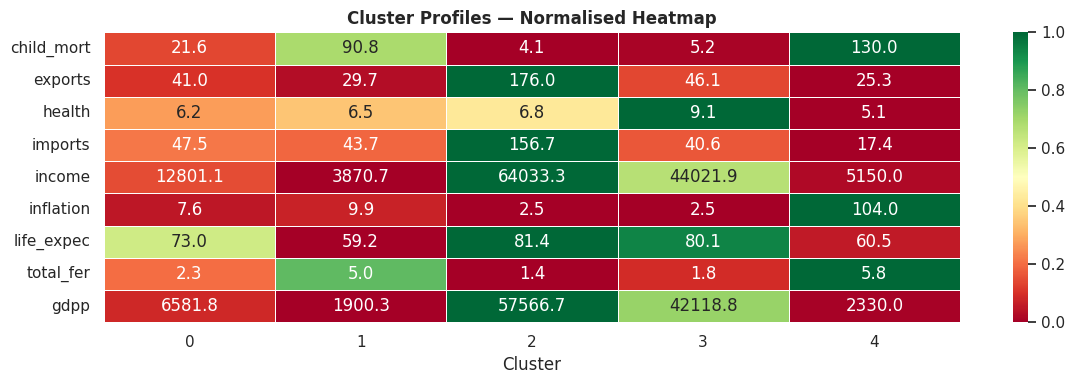

In [34]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
print("=== K-Means Cluster Profiles (mean values) ===")
display(profile)

# Heatmap of cluster profiles
plt.figure(figsize=(12, 4))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm.T, annot=profile.T.values, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Cluster Profiles — Normalised Heatmap', fontweight='bold')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

=== Clustering Evaluation ===
Note: Silhouette closer to 1 = better | Davies-Bouldin closer to 0 = better


,Silhouette,Davies-Bouldin
K-Means,0.30,0.87
Hierarchical,0.22,1.30


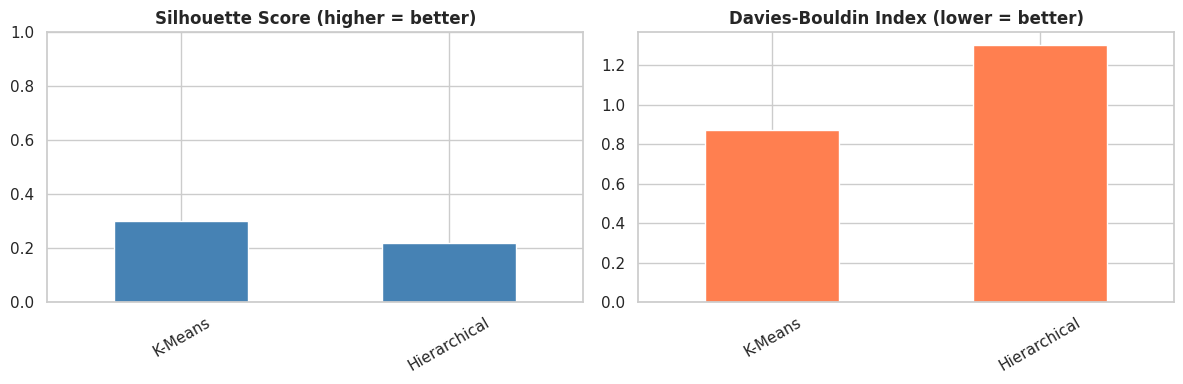

In [35]:
eval_results = {
    'K-Means':       {'Silhouette': round(silhouette_score(X_scaled, df['kmeans_cluster']), 4),
                      'Davies-Bouldin': round(davies_bouldin_score(X_scaled, df['kmeans_cluster']), 4)},
    'Hierarchical':  {'Silhouette': round(sil_a, 4),
                      'Davies-Bouldin': round(db_a, 4)},
}

if KMEDOIDS_AVAILABLE:
    eval_results['K-Medoids'] = {
        'Silhouette': round(sil_km, 4),
        'Davies-Bouldin': round(db_km, 4)
    }

eval_df = pd.DataFrame(eval_results).T
print("=== Clustering Evaluation ===")
print("Note: Silhouette closer to 1 = better | Davies-Bouldin closer to 0 = better")
display(eval_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eval_df['Silhouette'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

eval_df['Davies-Bouldin'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()